<a href="https://colab.research.google.com/github/holehouse-lab/soursop/blob/master/ped-resources/ped_ensemble_characterisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biophysical characterisation of a PED ensemble

This notebook takes any ensemble from the [Protein Ensemble Database (PED)](https://proteinensemble.org) and characterises it, comparing it with simple polymer models of the same length:

1. **Radius of gyration**, the overall size of the chain.
2. **End-to-end distance**, the distance between the two ends.
3. **Helicity**, how often each residue is in a helix.
4. **β-strand content**, how often each residue is in a β-strand.
5. **Distance map**, the average distance between every pair of residues.
6. **Distance between two residues** of your choice.
7. **Scaling map**, which regions are more expanded or more compact than a random coil of the same sequence.
8. **Shape**, the size and shape of every conformer.

First, though, [metapredict](https://github.com/idptools/metapredict) predicts which parts of the sequence are disordered, and warns you if any are predicted to be folded, since the polymer models are for disordered proteins.

### How to use it

1. Type the identifier of a PED ensemble into the `PED_ID` box below.
2. Choose **Runtime → Run all** from the menu. If Colab warns that the notebook was not written by Google, choose **Run anyway**.
3. Scroll down through the results. The whole notebook takes a minute or two.

You don't need to read or change any code. It is hidden, and each step shows only its results. (To see the code behind a step, click **Show code** on it.)

The analysis uses [SOURSOP](https://soursop.readthedocs.io), [afrc](https://github.com/idptools/afrc) and [metapredict](https://github.com/idptools/metapredict).

## Choose an ensemble

* **PED_ID**: a PED ensemble identifier, such as `PED00184e001`. You can also give just the entry (`PED00184`) if it holds only one ensemble. Find identifiers by searching [PED](https://proteinensemble.org). The default is an NMR-refined ensemble of the Tif2 nuclear receptor interaction domain (500 conformers, 154 residues).
* **N_AFRC** and **N_SAW**: the number of conformers in the reference models. The defaults are fine.
* **SAVE_FIGURES**: tick this to save every figure as a PDF and download them all at the end.

In [1]:
# @title Choose a PED ensemble
PED_ID = "PED00184e001"  # @param {type:"string"}
N_AFRC = 50000  # @param {type:"integer"}
N_SAW = 20000  # @param {type:"integer"}
SAVE_FIGURES = False  # @param {type:"boolean"}

## Install and set up

These two steps install SOURSOP, afrc and metapredict, which Colab does not come with, and prepare the analysis. They take about a minute.

In [ ]:
# @title Install SOURSOP, afrc and metapredict
# This uses uv, which is much faster than pip (and is itself installed first if
# it is missing); --system installs into Colab's own Python. SOURSOP's PED
# module is new in 2.0.8 and afrc's ensemble building is new in 0.5.0; until
# those versions are on PyPI, they are installed from GitHub instead.
!command -v uv >/dev/null || pip install -q uv
!uv pip install --system -q "soursop>=2.0.8" 2>/dev/null || uv pip install --system -q "git+https://github.com/holehouse-lab/soursop.git"
!uv pip install --system -q "afrc>=0.5.0" 2>/dev/null || uv pip install --system -q "git+https://github.com/idptools/afrc.git@ensemble"
!uv pip install --system -q metapredict
print("SOURSOP, afrc and metapredict are installed")

In [3]:
# @title Set up the analysis
# Everything the notebook does is defined here, as functions; the steps below
# just call them.

# draw figures at twice the resolution, so they are crisp on high-resolution screens
%config InlineBackend.figure_format = "retina"

import os
import shutil
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib.pyplot as plt
import metapredict
import numpy as np
from IPython.display import HTML, display
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

from afrc import AnalyticalFRC
from afrc.polymer_models.nudep_saw import NuDepSAW
from soursop import ped
from soursop.ssexceptions import SSException
from soursop.ssprotein import SSProtein
from soursop.sstrajectory import SSTrajectory

# Figure style: Arial throughout, text kept editable in Illustrator, no grid
# lines, and the xmgrace colour order (black, red, blue, green, purple).
# Colab does not have Arial, so there figures fall back to Liberation Sans
# (metrically identical to Arial) or matplotlib's default, DejaVu Sans
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.linewidth": 1.0,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.grid": False,
    "axes.prop_cycle": plt.cycler(color=["black", "red", "blue", "green", "purple"]),
})

# SAW-nu reference models: scaling exponents, their colours, and the size scale
# (the root-mean-square distance between residues k apart is SAW_PREFACTOR * k**nu)
SAW_NUS = (0.33, 0.5, 0.589)
SAW_COLOURS = {0.33: "red", 0.5: "blue", 0.589: "green"}
SAW_PREFACTOR = 5.5  # Angstroms

SCALING_RANGE = 0.3  # the scaling map's colour scale starts at 1 +/- this (adjustable with a slider)
MIN_SEPARATION = 10  # residue pairs closer than this in sequence are left out of the scaling map
N_BOOTSTRAP = 100  # resampled ensembles used to show the spread in per-residue secondary structure
SEED = 1  # makes the reference ensembles and the resampling reproducible
DISORDER_THRESHOLD = 0.5  # metapredict (V3) scores above this are predicted disordered

CACHE = "ped_cache"  # downloaded PED ensembles
MODEL_DIR = "reference_ensembles"  # AFRC and SAW-nu ensembles
FIGURE_DIR = "figures"

# afrc needs the sequence. The AFRC only knows the 20 standard amino acids, so
# common variants and modified residues are mapped onto their parent residue
# (e.g. phosphoserine onto serine); caps, which have no CA, are left out
ONE_LETTER = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q", "GLU": "E",
    "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F",
    "PRO": "P", "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
    "HID": "H", "HIE": "H", "HIP": "H", "HSD": "H", "HSE": "H", "HSP": "H", "ASH": "D",
    "GLH": "E", "LYN": "K", "CYX": "C", "CYM": "C", "SEP": "S", "TPO": "T", "PTR": "Y",
    "MSE": "M",
}


@dataclass
class Ensemble:
    """A PED ensemble read into SOURSOP, with the properties of each conformer.

    Attributes
    ----------
    identifier : str
        The PED identifier the ensemble was loaded with.
    title : str
        The title of the PED entry.
    protein : SSProtein
        The protein chain (the first, if there are several), one frame per
        conformer.
    weights : np.ndarray or None
        Per-conformer weights from PED, normalised to sum to 1, or None if
        every conformer counts equally.
    sequence : str
        One-letter sequence of the residues that have a CA atom, with modified
        residues mapped onto their parent residue.
    rg : np.ndarray
        Radius of gyration of each conformer (Angstroms).
    re : np.ndarray
        Distance between the CA atoms of the first and last residues in each
        conformer (Angstroms).
    asphericity : np.ndarray
        Asphericity of each conformer (0 for a sphere, 1 for a rod).
    """

    identifier: str
    title: str
    protein: SSProtein
    weights: Optional[np.ndarray]
    sequence: str
    rg: np.ndarray
    re: np.ndarray
    asphericity: np.ndarray

    # calculated the first time they are needed, then kept
    _secondary_structure: Optional[Dict[str, np.ndarray]] = field(default=None, init=False, repr=False)
    _dssp_error: Optional[str] = field(default=None, init=False, repr=False)
    _disorder: Optional[Tuple[np.ndarray, List[Tuple[int, int]]]] = field(default=None, init=False, repr=False)

    def secondary_structure(self) -> Optional[Dict[str, np.ndarray]]:
        """Classify every residue in every conformer with DSSP.

        This is calculated the first time it is needed, then kept.

        Returns
        -------
        dict or None
            ``{"helix": ..., "strand": ...}``, each an array of shape
            (conformers, residues) that is 1 where a residue is in that
            structure and 0 otherwise. None (with a message saying why) if DSSP
            cannot be run, e.g. for an ensemble with only CA atoms, which has
            no backbone to classify.
        """
        if self._secondary_structure is None and self._dssp_error is None:
            try:
                _, helix, strand, _ = self.protein.get_secondary_structure_DSSP(return_per_frame=True)
                self._secondary_structure = {"helix": np.asarray(helix), "strand": np.asarray(strand)}
            except SSException as error:
                self._dssp_error = str(error)
        if self._secondary_structure is None:
            print(f"Secondary structure cannot be calculated for this ensemble, since DSSP needs a full "
                  f"backbone ({self._dssp_error})")
        return self._secondary_structure

    def disorder(self) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
        """Predict disorder from the sequence with metapredict.

        This is calculated the first time it is needed, then kept.

        Returns
        -------
        tuple
            ``(scores, folded)``: the metapredict disorder score of every
            residue (0 to 1; above ``DISORDER_THRESHOLD`` is predicted
            disordered), and a list of the predicted folded domains as
            ``(first, last)`` residue numbers, counting from 1.
        """
        if self._disorder is None:
            domains = metapredict.predict_disorder_domains(self.sequence, disorder_threshold=DISORDER_THRESHOLD)
            folded = [(int(start) + 1, int(end)) for start, end in domains.folded_domain_boundaries]
            self._disorder = (np.asarray(domains.disorder, dtype=float), folded)
        return self._disorder

    @property
    def n_conformers(self) -> int:
        """Number of conformers in the ensemble."""
        return int(self.protein.n_frames)

    @property
    def n_residues(self) -> int:
        """Number of residues (those with a CA atom)."""
        return len(self.sequence)

    @property
    def residues(self) -> np.ndarray:
        """Residue numbers used on every plot, from 1 to ``n_residues``."""
        return np.arange(1, self.n_residues + 1)

    @property
    def point_alpha(self) -> float:
        """Transparency for plots with one point per conformer.

        Points are more transparent for larger ensembles, so that overlapping
        points show where the conformers are densest.
        """
        return float(np.clip(80 / self.n_conformers, 0.2, 0.8))

    def mean(self, values: np.ndarray) -> float:
        """Average a per-conformer quantity, using the PED weights if there are any.

        Parameters
        ----------
        values : np.ndarray
            One value per conformer.

        Returns
        -------
        float
            The (weighted) mean.
        """
        return float(np.average(values, weights=self.weights))


@dataclass
class References:
    """The polymer reference models built for one ensemble.

    Attributes
    ----------
    saw : NuDepSAW
        The self-avoiding walk model with a set scaling exponent (SAW-nu).
    saw_rg : dict
        Radius of gyration of every conformer in each SAW-nu ensemble (Angstroms),
        keyed by the scaling exponent.
    afrc : AnalyticalFRC
        The Analytical Flory Random Coil for the sequence.
    afrc_rg : np.ndarray
        Radius of gyration of every conformer in the AFRC ensemble (Angstroms).
    afrc_asphericity : np.ndarray
        Asphericity of every conformer in the AFRC ensemble.
    """

    saw: NuDepSAW
    saw_rg: Dict[float, np.ndarray]
    afrc: AnalyticalFRC
    afrc_rg: np.ndarray
    afrc_asphericity: np.ndarray


def load_ped_ensemble(identifier: str) -> Ensemble:
    """Download an ensemble from PED, read it into SOURSOP and measure every conformer.

    Parameters
    ----------
    identifier : str
        PED ensemble identifier (e.g. ``"PED00184e001"``), or an entry
        identifier if the entry holds a single ensemble.

    Returns
    -------
    Ensemble
        The ensemble, with the radius of gyration, end-to-end distance and
        asphericity of every conformer.

    Raises
    ------
    ValueError
        If the ensemble cannot be loaded from PED, or contains a residue with
        no one-letter code.
    """
    identifier = identifier.strip()
    try:
        entry = ped.get_entry(identifier)
        trajectory = ped.load_ensemble(identifier, cache_dir=CACHE)
    except SSException as error:
        raise ValueError(
            f"Could not load '{identifier}' from PED. Check the identifier, which should look "
            f"like PED00184e001.\n\nPED said: {error}"
        ) from None

    protein = trajectory.proteinTrajectoryList[0]
    if len(trajectory.proteinTrajectoryList) > 1:
        print(f"This ensemble has {len(trajectory.proteinTrajectoryList)} chains; analysing the first.")

    # PED also serves weights for unweighted ensembles (all equal), which we
    # treat as no weights
    weights = ped.get_ensemble_weights(identifier)
    if weights is not None and np.allclose(weights, weights[0]):
        weights = None

    names = protein.get_amino_acid_sequence(numbered=False)
    unknown = sorted({names[i] for i in protein.resid_with_CA} - set(ONE_LETTER))
    if unknown:
        raise ValueError(f"This ensemble contains residue(s) {unknown}, which have no one-letter code")
    sequence = "".join(ONE_LETTER[names[i]] for i in protein.resid_with_CA)

    ensemble = Ensemble(
        identifier=identifier,
        title=entry.title,
        protein=protein,
        weights=weights,
        sequence=sequence,
        rg=protein.get_radius_of_gyration(),
        re=protein.get_end_to_end_distance(mode="CA"),
        asphericity=protein.get_asphericity(verbose=False),
    )
    print(f"{identifier}: {entry.title}")
    print(f"{ensemble.n_conformers} conformers, {ensemble.n_residues} residues, "
          f"{'weighted' if weights is not None else 'unweighted'}")
    print(f"Sequence: {sequence}")
    return ensemble


def _warn(message: str) -> None:
    """Show a warning in a highlighted box, so it stands out from the rest of the output.

    Parameters
    ----------
    message : str
        The warning (may contain HTML).
    """
    display(HTML(
        '<div style="border-left: 5px solid #d62728; background: #fdecea; color: #222; '
        f'padding: 10px 14px; margin: 8px 0; font-size: 14px;"><b>⚠️ Warning:</b> {message}</div>'
    ))


def _residue_ranges(domains: List[Tuple[int, int]]) -> str:
    """Write a list of residue ranges in words, e.g. "residues 1–71 and 120–180".

    Parameters
    ----------
    domains : list of tuple
        ``(first, last)`` residue numbers (at least one range).

    Returns
    -------
    str
        The ranges in words.
    """
    ranges = [f"{first}–{last}" for first, last in domains]
    joined = ranges[0] if len(ranges) == 1 else ", ".join(ranges[:-1]) + " and " + ranges[-1]
    return f"residues {joined}"


def plot_disorder(ensemble: Ensemble, save: bool = False) -> None:
    """Plot metapredict's per-residue disorder prediction, and warn about any folded domains.

    The polymer reference models describe fully disordered chains, so if
    metapredict predicts folded domains, comparisons with them are less
    meaningful and a warning is shown.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    scores, folded = ensemble.disorder()

    fig, ax = plt.subplots(figsize=(9.5, 3.6), constrained_layout=True)
    for first, last in folded:
        ax.axvspan(first - 0.5, last + 0.5, color="blue", alpha=0.12, lw=0)
    ax.axhline(DISORDER_THRESHOLD, color="red", lw=1.2)
    ax.plot(ensemble.residues, scores, color="black", lw=1.8)
    ax.set_xlim(0.5, ensemble.n_residues + 0.5)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Residue")
    ax.set_ylabel("Disorder score")
    handles = [
        Line2D([], [], color="black", lw=1.8, label="metapredict disorder score"),
        Line2D([], [], color="red", lw=1.2, label=f"Threshold ({DISORDER_THRESHOLD}): above is disordered"),
    ]
    if folded:
        handles.append(Patch(color="blue", alpha=0.12, lw=0, label="Predicted folded domain"))
    # the legend goes above the plot, where it can't cover the scores (which may be high or low)
    ax.legend(handles=handles, frameon=False, fontsize=10, loc="lower left", bbox_to_anchor=(0, 1.0),
              ncol=len(handles), borderaxespad=0.3)
    _finish(fig, ensemble, "disorder", save)

    disordered = np.mean(scores > DISORDER_THRESHOLD)
    print(f"{disordered:.0%} of residues are predicted to be disordered")
    if folded:
        n_folded = sum(last - first + 1 for first, last in folded)
        _warn(
            f"metapredict predicts a folded domain at {_residue_ranges(folded)} ({n_folded} of "
            f"{ensemble.n_residues} residues). The reference models used below (SAW-ν and the AFRC) "
            "describe fully disordered chains, so comparisons with them are less meaningful for this "
            "protein. Interpret the radius of gyration, end-to-end distance, scaling map and shape "
            "comparisons with care."
        )


def _build_and_load(model, name: str, n: int, **parameters) -> SSProtein:
    """Build a reference ensemble with afrc, save it, and read it into SOURSOP.

    Parameters
    ----------
    model : AnalyticalFRC or NuDepSAW
        Any afrc model with a ``save_ensemble()`` method.
    name : str
        File name (without extension) for the PDB/XTC pair, written in
        ``MODEL_DIR``.
    n : int
        Number of conformers to build.
    **parameters
        Model parameters passed on to ``save_ensemble()`` (e.g. ``nu``).

    Returns
    -------
    SSProtein
        The reference ensemble, one frame per conformer.
    """
    os.makedirs(MODEL_DIR, exist_ok=True)
    path = os.path.join(MODEL_DIR, name)
    model.save_ensemble(path, n=n, seed=SEED, **parameters)
    return SSTrajectory(path + ".xtc", path + ".pdb").proteinTrajectoryList[0]


def build_reference_ensembles(ensemble: Ensemble, n_afrc: int, n_saw: int) -> References:
    """Build the SAW-nu and AFRC reference ensembles for an ensemble's sequence.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble; only its sequence (and length) is used.
    n_afrc : int
        Number of conformers in the AFRC ensemble.
    n_saw : int
        Number of conformers in each SAW-nu ensemble.

    Returns
    -------
    References
        The reference models, and the radius of gyration (and, for the AFRC,
        asphericity) of every conformer in their ensembles.
    """
    # SAW-nu: one ensemble per scaling exponent. Only Rg is needed from these,
    # since the end-to-end distance distribution is known analytically
    saw = NuDepSAW(ensemble.sequence)
    saw_rg = {}
    for nu in SAW_NUS:
        name = f"saw_nu_{nu}".replace(".", "_")
        saw_rg[nu] = _build_and_load(saw, name, n_saw, nu=nu, prefactor=SAW_PREFACTOR).get_radius_of_gyration()

    afrc = AnalyticalFRC(ensemble.sequence)
    afrc_protein = _build_and_load(afrc, "afrc", n_afrc)
    references = References(
        saw=saw,
        saw_rg=saw_rg,
        afrc=afrc,
        afrc_rg=afrc_protein.get_radius_of_gyration(),
        afrc_asphericity=afrc_protein.get_asphericity(verbose=False),
    )
    print(f"Built {len(SAW_NUS)} SAW-ν ensembles of {n_saw:,} conformers and an AFRC ensemble of {n_afrc:,}")
    return references


def _finish(fig: Figure, ensemble: Ensemble, name: str, save: bool) -> None:
    """Show a figure, and also save it as a PDF if asked to.

    Parameters
    ----------
    fig : Figure
        The figure.
    ensemble : Ensemble
        The ensemble shown (its identifier goes in the file name).
    name : str
        Short name for the figure; the PDF is saved as
        ``figures/<identifier>_<name>.pdf``.
    save : bool
        Whether to save the PDF.
    """
    if save:
        os.makedirs(FIGURE_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIGURE_DIR, f"{ensemble.identifier}_{name}.pdf"))
    plt.show()


def _mark_mean(ax: Axes, value: float, colour: str) -> None:
    """Mark a mean with a triangle along the top of the axes.

    Parameters
    ----------
    ax : Axes
        The axes to mark.
    value : float
        The mean, in data units along x.
    colour : str
        Colour of the triangle.
    """
    ax.plot(value, 1.0, "v", color=colour, ms=9, transform=ax.get_xaxis_transform(), clip_on=False)


def _describe(value: float, references: Dict[float, float]) -> str:
    """Say where a mean sits among the SAW-nu reference means.

    Parameters
    ----------
    value : float
        The ensemble's mean (Angstroms).
    references : dict
        The mean of each SAW-nu reference (Angstroms), keyed by the scaling
        exponent.

    Returns
    -------
    str
        A short description, e.g. "between the ν = 0.5 (27.0 Å) and
        ν = 0.589 (39.1 Å) references".
    """
    ordered = sorted(references.items(), key=lambda item: item[1])
    if value < ordered[0][1]:
        return f"below even the ν = {ordered[0][0]} reference ({ordered[0][1]:.1f} Å)"
    for (nu_low, low), (nu_high, high) in zip(ordered, ordered[1:]):
        if value <= high:
            return f"between the ν = {nu_low} ({low:.1f} Å) and ν = {nu_high} ({high:.1f} Å) references"
    return f"above even the ν = {ordered[-1][0]} reference ({ordered[-1][1]:.1f} Å)"


def plot_radius_of_gyration(ensemble: Ensemble, references: References, save: bool = False) -> None:
    """Plot the radius of gyration distribution against the SAW-nu references.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    mean = ensemble.mean(ensemble.rg)
    saw_means = {nu: float(values.mean()) for nu, values in references.saw_rg.items()}
    upper = 1.05 * max(ensemble.rg.max(), np.percentile(references.saw_rg[max(SAW_NUS)], 99.5))
    grid = np.linspace(0, upper, 400)

    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    for nu in SAW_NUS:
        # a kernel density estimate gives a smooth curve from the sampled ensemble
        ax.plot(grid, gaussian_kde(references.saw_rg[nu])(grid), color=SAW_COLOURS[nu], lw=1.8,
                label=f"SAW, ν = {nu} (mean {saw_means[nu]:.1f} Å)")
        _mark_mean(ax, saw_means[nu], SAW_COLOURS[nu])
    ax.hist(ensemble.rg, bins=np.histogram_bin_edges(ensemble.rg, bins="auto"), weights=ensemble.weights,
            density=True, histtype="step", color="black", lw=2, label=f"{ensemble.identifier} (mean {mean:.1f} Å)")
    _mark_mean(ax, mean, "black")
    ax.set_xlim(0, upper)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Radius of gyration (Å)")
    ax.set_ylabel("Probability density (1/Å)")
    ax.legend(frameon=False, fontsize=10)
    _finish(fig, ensemble, "rg", save)
    print(f"Mean radius of gyration {mean:.1f} Å: {_describe(mean, saw_means)}")


def plot_end_to_end_distance(ensemble: Ensemble, references: References, save: bool = False) -> None:
    """Plot the end-to-end distance distribution against the SAW-nu references.

    The SAW-nu end-to-end distributions are the exact analytical ones.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    mean = ensemble.mean(ensemble.re)
    saw = {nu: references.saw.get_end_to_end_distribution(nu=nu, prefactor=SAW_PREFACTOR) for nu in SAW_NUS}
    saw_means = {nu: float(np.sum(r * p)) for nu, (r, p) in saw.items()}
    r, p = saw[max(SAW_NUS)]
    upper = 1.05 * max(ensemble.re.max(), r[np.searchsorted(np.cumsum(p), 0.995)])

    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    for nu, (r, p) in saw.items():
        # p is a probability per grid point, so divide by the grid spacing for a density
        ax.plot(r, p / (r[1] - r[0]), color=SAW_COLOURS[nu], lw=1.8,
                label=f"SAW, ν = {nu} (mean {saw_means[nu]:.1f} Å)")
        _mark_mean(ax, saw_means[nu], SAW_COLOURS[nu])
    ax.hist(ensemble.re, bins=np.histogram_bin_edges(ensemble.re, bins="auto"), weights=ensemble.weights,
            density=True, histtype="step", color="black", lw=2, label=f"{ensemble.identifier} (mean {mean:.1f} Å)")
    _mark_mean(ax, mean, "black")
    ax.set_xlim(0, upper)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("End-to-end distance (Å)")
    ax.set_ylabel("Probability density (1/Å)")
    ax.legend(frameon=False, fontsize=10)
    _finish(fig, ensemble, "re", save)
    print(f"Mean end-to-end distance {mean:.1f} Å: {_describe(mean, saw_means)}")


def _plot_secondary_structure(ensemble: Ensemble, kind: str, label: str, colour: str, name: str,
                              save: bool) -> None:
    """Plot one kind of secondary structure per residue, and per conformer.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    kind : str
        ``"helix"`` or ``"strand"``.
    label : str
        What to call it on the plot and in the printed summary (e.g.
        ``"helicity"``).
    colour : str
        Colour of the points.
    name : str
        Short name for the figure (used if it is saved).
    save : bool
        Also save the figure as a PDF.
    """
    structure = ensemble.secondary_structure()
    if structure is None:
        return
    in_structure = structure[kind]
    n = ensemble.n_conformers
    rng = np.random.default_rng(SEED)
    profile = np.average(in_structure, axis=0, weights=ensemble.weights)  # per residue
    per_conformer = in_structure.mean(axis=1)

    # each bootstrap resample, drawn with the conformer weights, is summarised by
    # how many times it picked each conformer; its profile is then a single
    # matrix product
    p = np.full(n, 1 / n) if ensemble.weights is None else ensemble.weights
    bootstrap = rng.multinomial(n, p, size=N_BOOTSTRAP) @ in_structure / n
    top = max(0.05, 1.05 * max(bootstrap.max(), per_conformer.max()))

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.2), sharey=True, constrained_layout=True,
                                  gridspec_kw={"width_ratios": [4, 1]})
    jitter = rng.uniform(-0.3, 0.3, size=bootstrap.shape)
    ax.scatter(ensemble.residues + jitter, bootstrap, s=4, color=colour, alpha=0.1, lw=0, rasterized=True)
    ax.plot(ensemble.residues, profile, color="black", lw=1.8)
    ax.set_xlim(0.5, ensemble.n_residues + 0.5)
    ax.set_ylim(0, top)
    ax.set_xlabel("Residue")
    ax.set_ylabel(f"Fractional {label}")

    ax2.scatter(rng.uniform(-0.3, 0.3, size=n), per_conformer, s=16, color=colour, alpha=ensemble.point_alpha, lw=0)
    ax2.plot([-0.4, 0.4], [ensemble.mean(per_conformer)] * 2, color="black", lw=2.5)
    ax2.set_xlim(-0.6, 0.6)
    ax2.set_xticks([])
    ax2.set_xlabel("Per conformer")
    _finish(fig, ensemble, name, save)

    most = int(np.argmax(profile))
    print(f"Mean {label} {ensemble.mean(per_conformer):.3f}; the highest is at "
          f"{ensemble.sequence[most]}{most + 1}, in {profile[most]:.0%} of the ensemble")


def plot_helicity(ensemble: Ensemble, save: bool = False) -> None:
    """Plot per-residue helicity (from DSSP), and the helicity of each conformer.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    _plot_secondary_structure(ensemble, "helix", "helicity", "red", "helicity", save)


def plot_beta_content(ensemble: Ensemble, save: bool = False) -> None:
    """Plot per-residue beta-strand content (from DSSP), and that of each conformer.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    _plot_secondary_structure(ensemble, "strand", "β-strand content", "blue", "beta_content", save)


def _mean_distance_map(ensemble: Ensemble) -> np.ndarray:
    """Mean CA-CA distance between every pair of residues.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.

    Returns
    -------
    np.ndarray
        Symmetric (residues x residues) map of mean distances (Angstroms).
    """
    weights = False if ensemble.weights is None else ensemble.weights  # SOURSOP's "unweighted" is False
    upper, _ = ensemble.protein.get_distance_map(mode="CA", weights=weights, verbose=False)
    return upper + upper.T  # SOURSOP returns the upper triangle; mirror it


def _show_map(ensemble: Ensemble, values: np.ndarray, label: str, name: str, save: bool,
              extend: str = "neither", **imshow) -> None:
    """Draw a residue-by-residue map with a colour bar.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    values : np.ndarray
        The (residues x residues) map.
    label : str
        Colour bar label.
    name : str
        Short name for the figure (used if it is saved).
    save : bool
        Also save the figure as a PDF.
    extend : str, optional
        Whether the colour bar shows arrows for values beyond its range
        (``"neither"``, ``"min"``, ``"max"`` or ``"both"``). Default ``"neither"``.
    **imshow
        Passed on to ``imshow`` (colour map, range and so on).
    """
    extent = [0.5, ensemble.n_residues + 0.5, ensemble.n_residues + 0.5, 0.5]
    fig, ax = plt.subplots(figsize=(6.6, 5.4), constrained_layout=True)
    image = ax.imshow(values, extent=extent, **imshow)
    ax.set_xlabel("Residue")
    ax.set_ylabel("Residue")
    fig.colorbar(image, ax=ax, shrink=0.85, extend=extend).set_label(label)
    _finish(fig, ensemble, name, save)


def _slider(description: str, value: float, low: float, high: float, step: float) -> widgets.FloatSlider:
    """A slider that redraws its plot when it is released (not while it is dragged).

    Parameters
    ----------
    description : str
        Label shown next to the slider.
    value : float
        Starting value.
    low, high : float
        Range of the slider.
    step : float
        Step between values.

    Returns
    -------
    widgets.FloatSlider
        The slider.
    """
    return widgets.FloatSlider(value=value, min=low, max=high, step=step, description=description,
                               continuous_update=False, readout_format=".2f" if step < 1 else ".0f",
                               style={"description_width": "initial"}, layout=widgets.Layout(width="480px"))


def plot_distance_map(ensemble: Ensemble, save: bool = False) -> None:
    """Plot the mean CA-CA distance between every pair of residues, with a slider for the colour scale.

    The slider sets the largest distance on the colour scale (anything further
    apart takes the lightest colour).

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    save : bool, optional
        Also save the figure (as drawn at the slider's current setting) as a
        PDF. Default False.
    """
    distances = _mean_distance_map(ensemble)
    largest = float(np.ceil(distances.max()))

    def draw(max_distance: float) -> None:
        extend = "max" if max_distance < distances.max() else "neither"
        _show_map(ensemble, distances, "Mean Cα-Cα distance (Å)", "distance_map", save,
                  extend=extend, cmap="plasma", vmin=0, vmax=max_distance)

    widgets.interact(draw, max_distance=_slider("Largest distance on the colour scale (Å)", largest,
                                                5, largest, 1))


def _residue_slider(description: str, value: int, n_residues: int) -> widgets.IntSlider:
    """A slider for choosing a residue, which redraws its plot when it is released.

    Parameters
    ----------
    description : str
        Label shown next to the slider.
    value : int
        Starting residue number.
    n_residues : int
        Number of residues (the slider runs from 1 to this).

    Returns
    -------
    widgets.IntSlider
        The slider. Clicking its number lets you type a residue in.
    """
    return widgets.IntSlider(value=value, min=1, max=n_residues, step=1, description=description,
                             continuous_update=False, style={"description_width": "initial"},
                             layout=widgets.Layout(width="480px"))


def plot_residue_distance(ensemble: Ensemble, references: References, save: bool = False) -> None:
    """Plot the distribution of the distance between two residues, with sliders to choose them.

    The distribution of the CA-CA distance across the ensemble is shown with
    the AFRC's distribution for the same pair of residues, and the means of
    both are reported.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    save : bool, optional
        Also save each figure drawn as a PDF (one per pair of residues).
        Default False.
    """
    n = ensemble.n_residues

    def draw(first_residue: int, second_residue: int) -> None:
        if first_residue == second_residue:
            print("Choose two different residues")
            return
        first, second = sorted((first_residue, second_residue))
        name_1, name_2 = f"{ensemble.sequence[first - 1]}{first}", f"{ensemble.sequence[second - 1]}{second}"

        # SOURSOP numbers residues its own way (from 0, including any caps), so
        # map our residue numbers (1 to N, CA-bearing residues only) onto its own
        resids = ensemble.protein.resid_with_CA
        distances = ensemble.protein.get_inter_residue_atomic_distance(resids[first - 1], resids[second - 1])
        mean = ensemble.mean(distances)
        r, p = references.afrc.get_interresidue_distance_distribution(first - 1, second - 1)
        afrc_mean = float(np.sum(r * p))
        upper = 1.05 * max(distances.max(), r[np.searchsorted(np.cumsum(p), 0.995)])

        fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
        # p is a probability per grid point, so divide by the grid spacing for a density
        ax.plot(r, p / (r[1] - r[0]), color="red", lw=1.8, label=f"AFRC (mean {afrc_mean:.1f} Å)")
        _mark_mean(ax, afrc_mean, "red")
        ax.hist(distances, bins=np.histogram_bin_edges(distances, bins="auto"), weights=ensemble.weights,
                density=True, histtype="step", color="black", lw=2,
                label=f"{ensemble.identifier} (mean {mean:.1f} Å)")
        _mark_mean(ax, mean, "black")
        ax.set_xlim(0, upper)
        ax.set_ylim(bottom=0)
        ax.set_xlabel(f"Cα-Cα distance between {name_1} and {name_2} (Å)")
        ax.set_ylabel("Probability density (1/Å)")
        ax.legend(frameon=False, fontsize=10)
        _finish(fig, ensemble, f"distance_{first}_{second}", save)
        print(f"Mean Cα-Cα distance between {name_1} and {name_2}: {mean:.1f} Å, which is "
              f"{mean / afrc_mean:.2f} times the AFRC's ({afrc_mean:.1f} Å)")

    widgets.interact(draw,
                     first_residue=_residue_slider("First residue", max(1, round(n / 4)), n),
                     second_residue=_residue_slider("Second residue", max(1, round(3 * n / 4)), n))


def plot_scaling_map(ensemble: Ensemble, references: References, save: bool = False) -> None:
    """Plot every mean inter-residue distance divided by the AFRC's, with a slider for the colour scale.

    Pairs closer than ``MIN_SEPARATION`` residues in sequence are left out.
    The slider sets how far the colour scale runs either side of 1 (from
    1 - x to 1 + x).

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    save : bool, optional
        Also save the figure (as drawn at the slider's current setting) as a
        PDF. Default False.
    """
    afrc_map = references.afrc.get_distance_map(symmetric_map=True)
    separation = np.abs(np.subtract.outer(ensemble.residues, ensemble.residues))
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(separation >= MIN_SEPARATION, _mean_distance_map(ensemble) / afrc_map, np.nan)
    cmap = plt.get_cmap("plasma").copy()
    cmap.set_bad("lightgrey")

    print(f"For pairs at least {MIN_SEPARATION} residues apart, distances are on average {np.nanmean(ratio):.2f} "
          f"times the AFRC's (from {np.nanmin(ratio):.2f} to {np.nanmax(ratio):.2f})")

    def draw(range_around_1: float) -> None:
        low, high = 1 - range_around_1, 1 + range_around_1
        below, above = np.nanmin(ratio) < low, np.nanmax(ratio) > high
        extend = {(True, True): "both", (True, False): "min", (False, True): "max"}.get((below, above), "neither")
        _show_map(ensemble, ratio, "Distance / AFRC distance", "scaling_map", save,
                  extend=extend, cmap=cmap, vmin=low, vmax=high)

    widgets.interact(draw, range_around_1=_slider("Colour scale: 1 ±", SCALING_RANGE, 0.05, 0.95, 0.05))


def plot_shape(ensemble: Ensemble, references: References, save: bool = False) -> None:
    """Plot radius of gyration against asphericity, over the AFRC's distribution.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    save : bool, optional
        Also save the figure as a PDF. Default False.
    """
    afrc_rg, afrc_asphericity = references.afrc_rg, references.afrc_asphericity
    x_low = 0.9 * min(np.percentile(afrc_rg, 0.1), ensemble.rg.min())
    x_high = 1.05 * max(np.percentile(afrc_rg, 99.9), ensemble.rg.max())

    # density of the AFRC ensemble on a grid, smoothed a little
    density, x_edges, y_edges = np.histogram2d(afrc_rg, afrc_asphericity, bins=100, range=[[x_low, x_high], [0, 1]])
    density = gaussian_filter(density, 1.5)
    x_centres = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_centres = 0.5 * (y_edges[1:] + y_edges[:-1])

    # the density levels whose contours enclose each fraction of the AFRC conformers
    enclosed = (0.95, 0.75, 0.5, 0.25)
    ordered = np.sort(density.ravel())[::-1]
    cumulative = np.cumsum(ordered) / ordered.sum()
    levels = [ordered[np.searchsorted(cumulative, q)] for q in enclosed]  # increasing density

    fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
    contours = ax.contour(x_centres, y_centres, density.T, levels=levels, colors="black", linewidths=1.1)
    ax.clabel(contours, fmt={level: f"{q:.0%}" for level, q in zip(levels, enclosed)}, fontsize=9)
    ax.scatter(ensemble.rg, ensemble.asphericity, s=16, color="red", lw=0, alpha=ensemble.point_alpha)
    ax.set_xlim(x_low, x_high)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Radius of gyration (Å)")
    ax.set_ylabel("Asphericity")
    ax.legend(handles=[
        Line2D([], [], marker="o", ls="", color="red", ms=6, label=ensemble.identifier),
        Line2D([], [], color="black", lw=1.1, label=f"AFRC ({len(afrc_rg):,} conformers)"),
    ], frameon=False, fontsize=10, loc="upper right")
    _finish(fig, ensemble, "rg_asphericity", save)


def print_summary(ensemble: Ensemble, references: References) -> None:
    """Print the ensemble's key properties next to the AFRC's.

    Parameters
    ----------
    ensemble : Ensemble
        The PED ensemble.
    references : References
        The reference models.
    """
    rg, re = ensemble.mean(ensemble.rg), ensemble.mean(ensemble.re)
    afrc_rg = references.afrc.get_mean_radius_of_gyration()
    afrc_re = references.afrc.get_mean_end_to_end_distance()
    rows = [
        ("Conformers", f"{ensemble.n_conformers}", ""),
        ("Residues", f"{ensemble.n_residues}", ""),
        ("Mean Rg (Å)", f"{rg:.1f}", f"{afrc_rg:.1f}"),
        ("Mean Re (Å)", f"{re:.1f}", f"{afrc_re:.1f}"),
        ("Mean asphericity", f"{ensemble.mean(ensemble.asphericity):.3f}", f"{references.afrc_asphericity.mean():.3f}"),
    ]
    structure = ensemble.secondary_structure()
    if structure is not None:
        rows.append(("Mean helicity", f"{ensemble.mean(structure['helix'].mean(axis=1)):.3f}", ""))
        rows.append(("Mean β content", f"{ensemble.mean(structure['strand'].mean(axis=1)):.3f}", ""))
    scores, folded = ensemble.disorder()
    rows.append(("Disordered (pred.)", f"{np.mean(scores > DISORDER_THRESHOLD):.0%}", ""))

    print(f"{'':20s}{ensemble.identifier:>14s}{'AFRC':>10s}")
    for label, value, reference in rows:
        print(f"{label:20s}{value:>14s}{reference:>10s}")
    print(f"\nRg / Rg(AFRC) = {rg / afrc_rg:.2f} and Re / Re(AFRC) = {re / afrc_re:.2f}. Above 1 means "
          "more expanded than a random coil of this sequence; below 1, more compact.")
    if folded:
        print(f"Note: metapredict predicts a folded domain at {_residue_ranges(folded)}, so the comparisons "
              "with the (disordered) reference models should be interpreted with care.")


def download_figures(ensemble: Ensemble) -> None:
    """Zip the saved figures and, in Colab, download them.

    Parameters
    ----------
    ensemble : Ensemble
        The ensemble shown (its identifier names the zip file).
    """
    archive = shutil.make_archive(f"{ensemble.identifier}_figures", "zip", FIGURE_DIR)
    try:
        from google.colab import files
    except ImportError:  # not running in Colab
        print(f"The figures are saved in {FIGURE_DIR}/ and zipped into {archive}")
        return
    files.download(archive)


print("Ready")

Ready


## Load the ensemble

The ensemble is downloaded from PED and read into SOURSOP, one frame per conformer. Some PED ensembles come with a weight for each conformer (from fitting to experimental data). If so, every average, histogram and map below uses the weights.

In [4]:
# @title Load the ensemble
ensemble = load_ped_ensemble(PED_ID)

PED00184e001: NMR RDC-refined ensemble of Tif2 NRID
500 conformers, 154 residues, unweighted
Sequence: GPHMERADGQSRLHDSKGQTKLLQLLTTKSDQMEPSPLASSLSDTNKDSTGSLPGSGSTHGTSLKEKHKILHRLLQDSSSPVDLAKLTAEATGKDLSQESSSTAPGSEVTIKQEPVSPKKKENALLRYLLDKDDTKDIGLPEITPKLERLDSKT


## Predicted disorder

[metapredict](https://github.com/idptools/metapredict) predicts how disordered each residue is from the sequence alone: scores above 0.5 are predicted disordered. The reference models used below describe fully disordered chains, so if part of the protein is predicted to be folded (shaded), a warning is shown and the comparisons with those models should be interpreted with care.

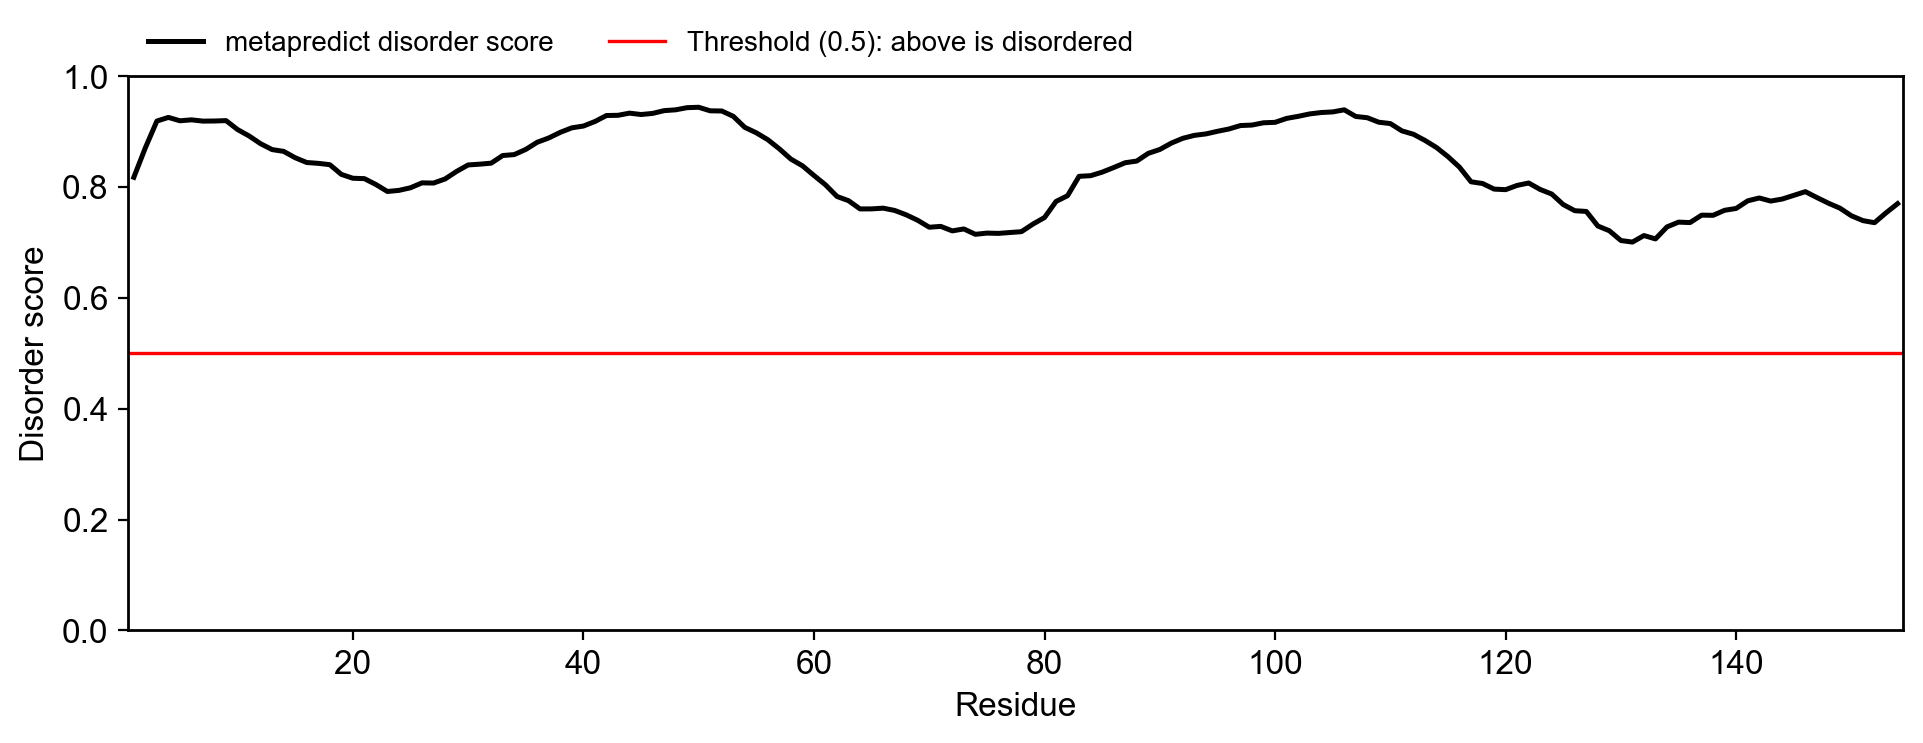

100% of residues are predicted to be disordered


In [5]:
# @title Predict disorder
plot_disorder(ensemble, save=SAVE_FIGURES)

## Build the reference models

To put the ensemble in context, we build two kinds of polymer model with exactly the same number of residues:

* **Self-avoiding walks with a set scaling exponent (SAW-ν)** [1, 2]. The scaling exponent ν describes how the size of a chain grows with its length: ν = 0.33 is a collapsed globule, 0.5 an ideal chain, and 0.589 an expanded chain in good solvent. (afrc builds these as a Gaussian approximation, which gets the size of every inter-residue distance right but gives a radius of gyration about 5% below that of a true self-avoiding walk.)
* **The Analytical Flory Random Coil (AFRC)** [3]: how this particular sequence would behave as a random coil, if its interactions with itself and with the solvent exactly cancelled out. We build a large AFRC ensemble so its distributions are smooth.

[1] Zheng, W. *et al.* (2018). Inferring properties of disordered chains from FRET transfer efficiencies. *J. Chem. Phys.* 148, 123329.
[2] Soranno, A. (2020). Physical basis of the disorder-order transition. *Arch. Biochem. Biophys.* 685, 108305.
[3] Alston, J. J., Ginell, G. M., Soranno, A. & Holehouse, A. S. (2023). The analytical Flory random coil is a simple-to-use reference model for unfolded and disordered proteins. *J. Phys. Chem. B* 127, 4746-4760.

In [6]:
# @title Build the reference models
references = build_reference_ensembles(ensemble, n_afrc=N_AFRC, n_saw=N_SAW)

Built 3 SAW-ν ensembles of 20,000 conformers and an AFRC ensemble of 50,000


## 1. Radius of gyration

The radius of gyration (Rg) measures the overall size of a conformer. The black histogram is the PED ensemble; the coloured lines are the SAW-ν models, from collapsed (red) to expanded (green). The triangles along the top mark the means.

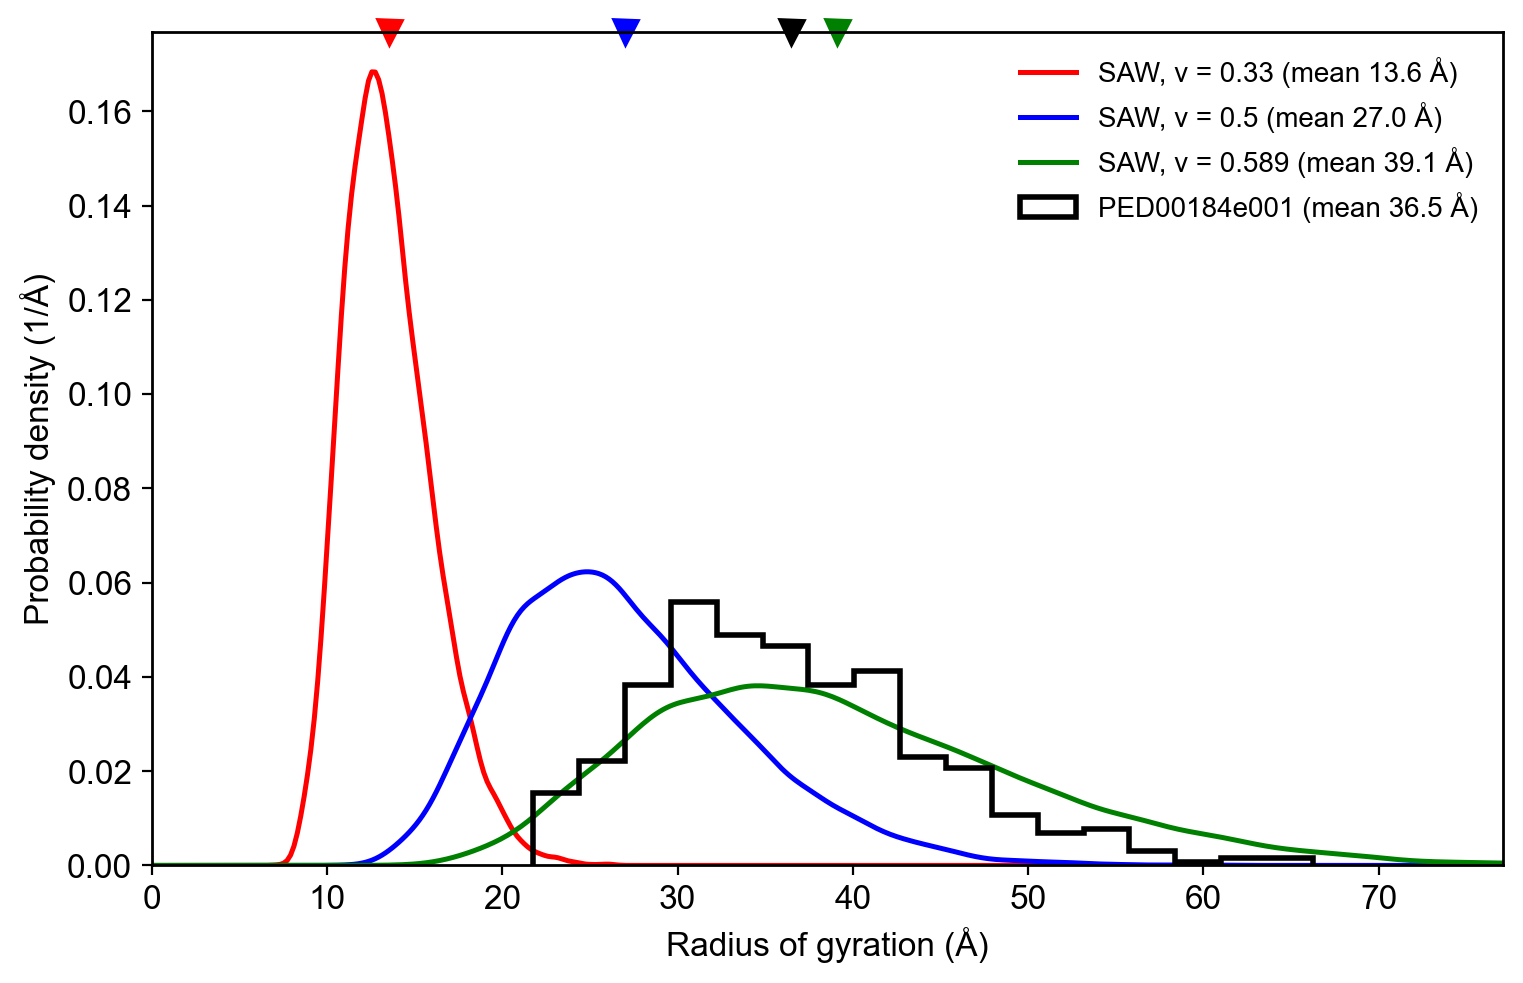

Mean radius of gyration 36.5 Å: between the ν = 0.5 (27.0 Å) and ν = 0.589 (39.1 Å) references


In [7]:
# @title Plot the radius of gyration
plot_radius_of_gyration(ensemble, references, save=SAVE_FIGURES)

## 2. End-to-end distance

The distance between the first and last residues (their Cα atoms), compared in the same way. For SAW-ν this distribution is known exactly, so the coloured lines are the analytical distributions.

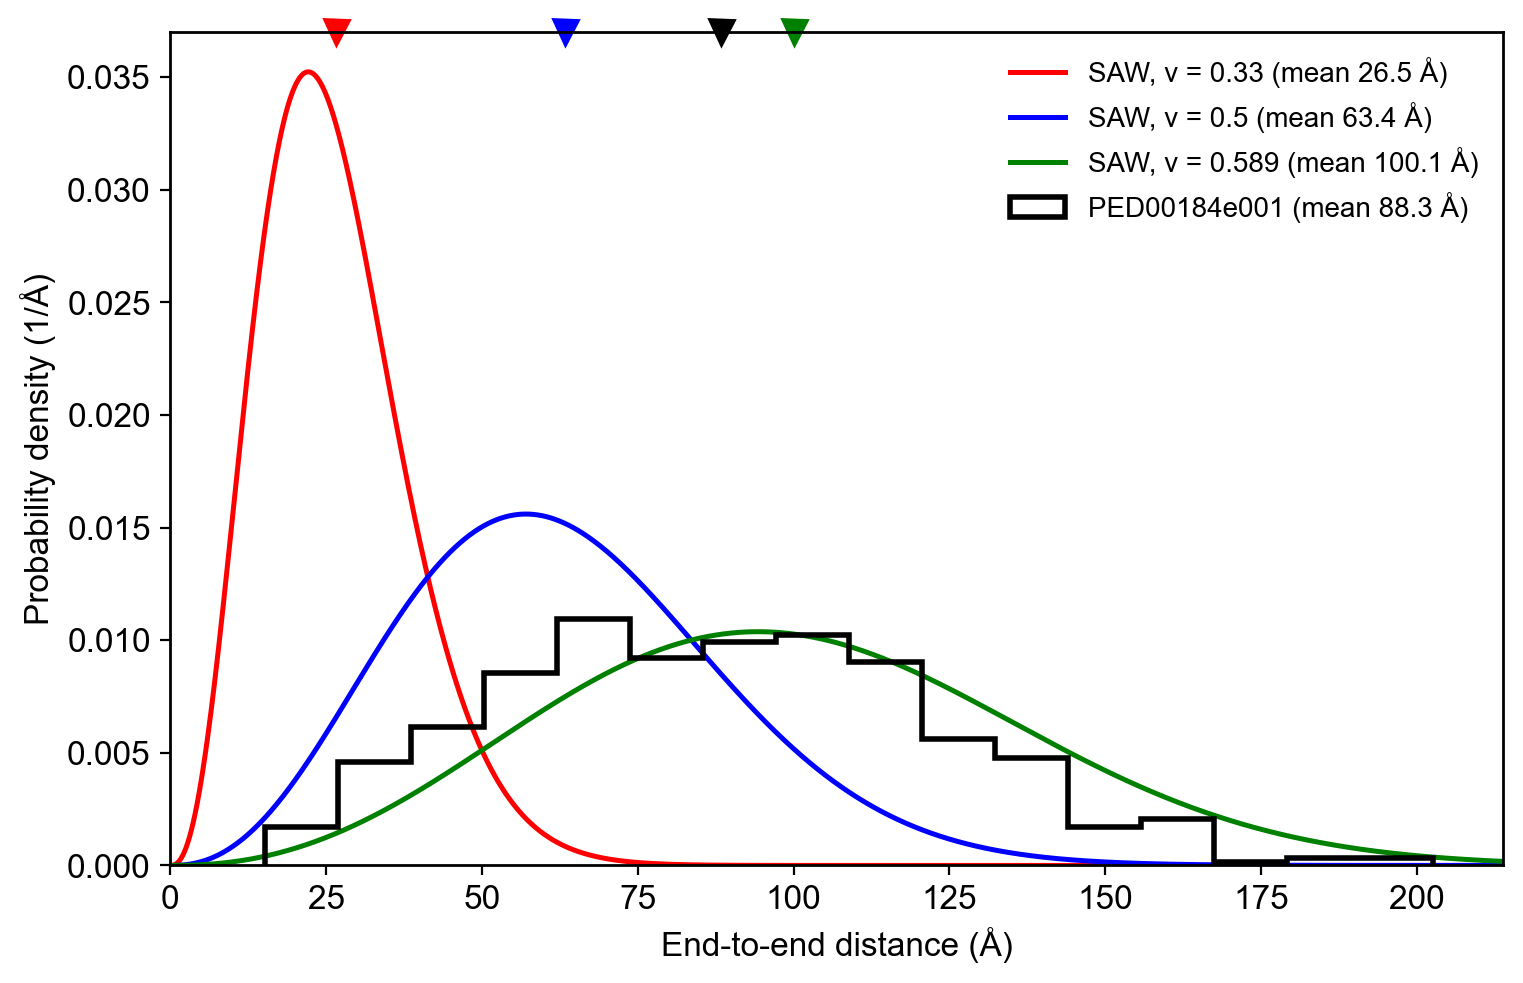

Mean end-to-end distance 88.3 Å: between the ν = 0.5 (63.4 Å) and ν = 0.589 (100.1 Å) references


In [8]:
# @title Plot the end-to-end distance
plot_end_to_end_distance(ensemble, references, save=SAVE_FIGURES)

## 3. Helicity

DSSP classifies every residue in every conformer as helix, β-strand or coil. Here we look at helix.

* **Left:** the fraction of conformers in which each residue is helical (black line). The red points show how much this profile changes between ensembles resampled from this one (one point per resample), a guide to how well a finite ensemble pins down each residue's helicity.
* **Right:** the fraction of residues that are helical in each conformer (one point per conformer; the black bar is the mean). A tight cloud means the helicity is spread evenly across the ensemble; a long tail means a few conformers hold most of it.

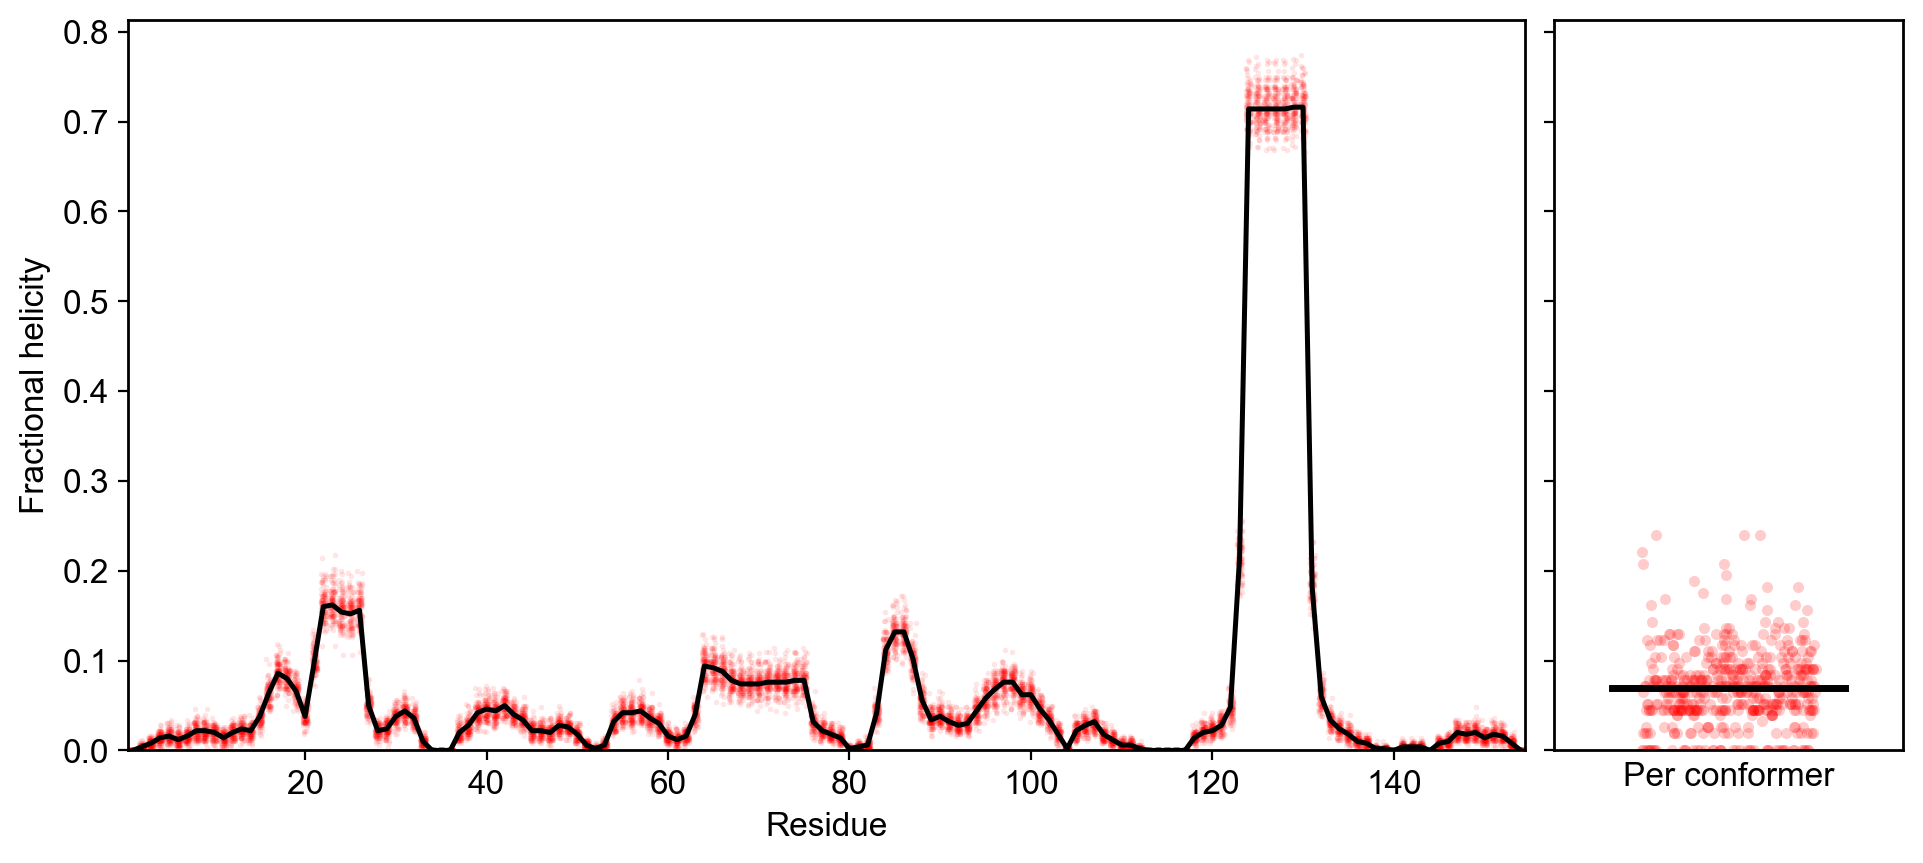

Mean helicity 0.070; the highest is at L129, in 72% of the ensemble


In [9]:
# @title Plot the helicity
plot_helicity(ensemble, save=SAVE_FIGURES)

## 4. β-strand content

The same for β-strands. DSSP counts a residue as β-strand when it forms β-sheet (or β-bridge) hydrogen bonds with another part of the chain. Disordered proteins rarely have much, but transient β-structure does occur.

* **Left:** the fraction of conformers in which each residue is in a β-strand (black line), with bootstrap resamples as blue points.
* **Right:** the fraction of residues in a β-strand in each conformer (the black bar is the mean).

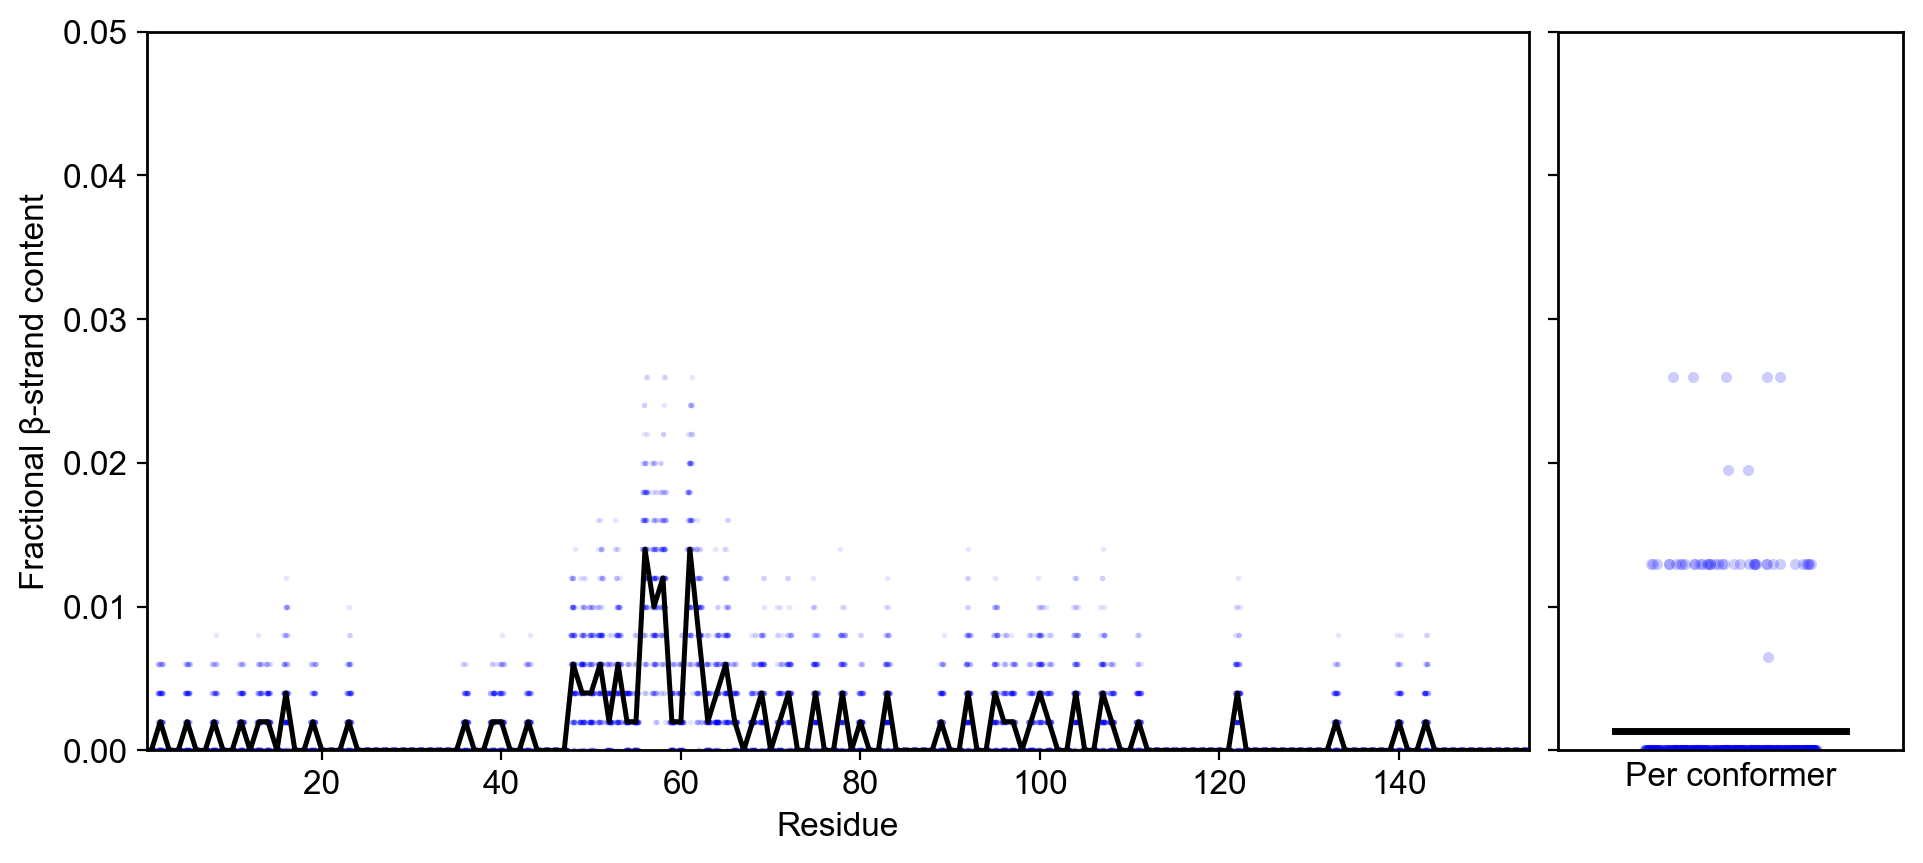

Mean β-strand content 0.001; the highest is at S56, in 1% of the ensemble


In [10]:
# @title Plot the β-strand content
plot_beta_content(ensemble, save=SAVE_FIGURES)

## 5. Distance map

The average distance between the Cα atoms of every pair of residues. Darker colours are closer together and lighter colours further apart. Use the slider to set the largest distance on the colour scale: lowering it brings out differences between nearby residues (anything further apart takes the lightest colour).

In [ ]:
# @title Plot the distance map
plot_distance_map(ensemble, save=SAVE_FIGURES)

## 6. Distance between two residues

Choose any two residues with the sliders (click the number next to a slider to type one in). The black histogram is the distribution of the Cα-Cα distance between them across the ensemble, and the red line is the AFRC's distribution for the same pair, i.e. what a random coil of this sequence would give. The triangles mark the means.

In [ ]:
# @title Plot the distance between two residues
plot_residue_distance(ensemble, references, save=SAVE_FIGURES)

## 7. Scaling map (normalised by the AFRC)

Each average inter-residue distance divided by the AFRC's prediction for the same pair of residues. Darker pairs are closer together than in a random coil of this sequence (more compact), and lighter pairs further apart (more expanded); 1 means the same as the random coil. The colour scale starts at 0.7 to 1.3 for every ensemble, so maps from different ensembles can be compared directly; use the slider to widen or narrow it (it stays centred on 1). Values beyond the scale take the end colours. Pairs fewer than 10 residues apart in sequence are left out (grey), since at such short range the AFRC is not a good model of the chain.

In [ ]:
# @title Plot the scaling map
plot_scaling_map(ensemble, references, save=SAVE_FIGURES)

## 8. Shape: radius of gyration against asphericity

Each red point is one conformer of the PED ensemble, drawn semi-transparent so that darker regions hold more conformers. The black contours enclose 25, 50, 75 and 95% of the AFRC ensemble. Asphericity describes shape: 0 for a sphere and 1 for a rod.

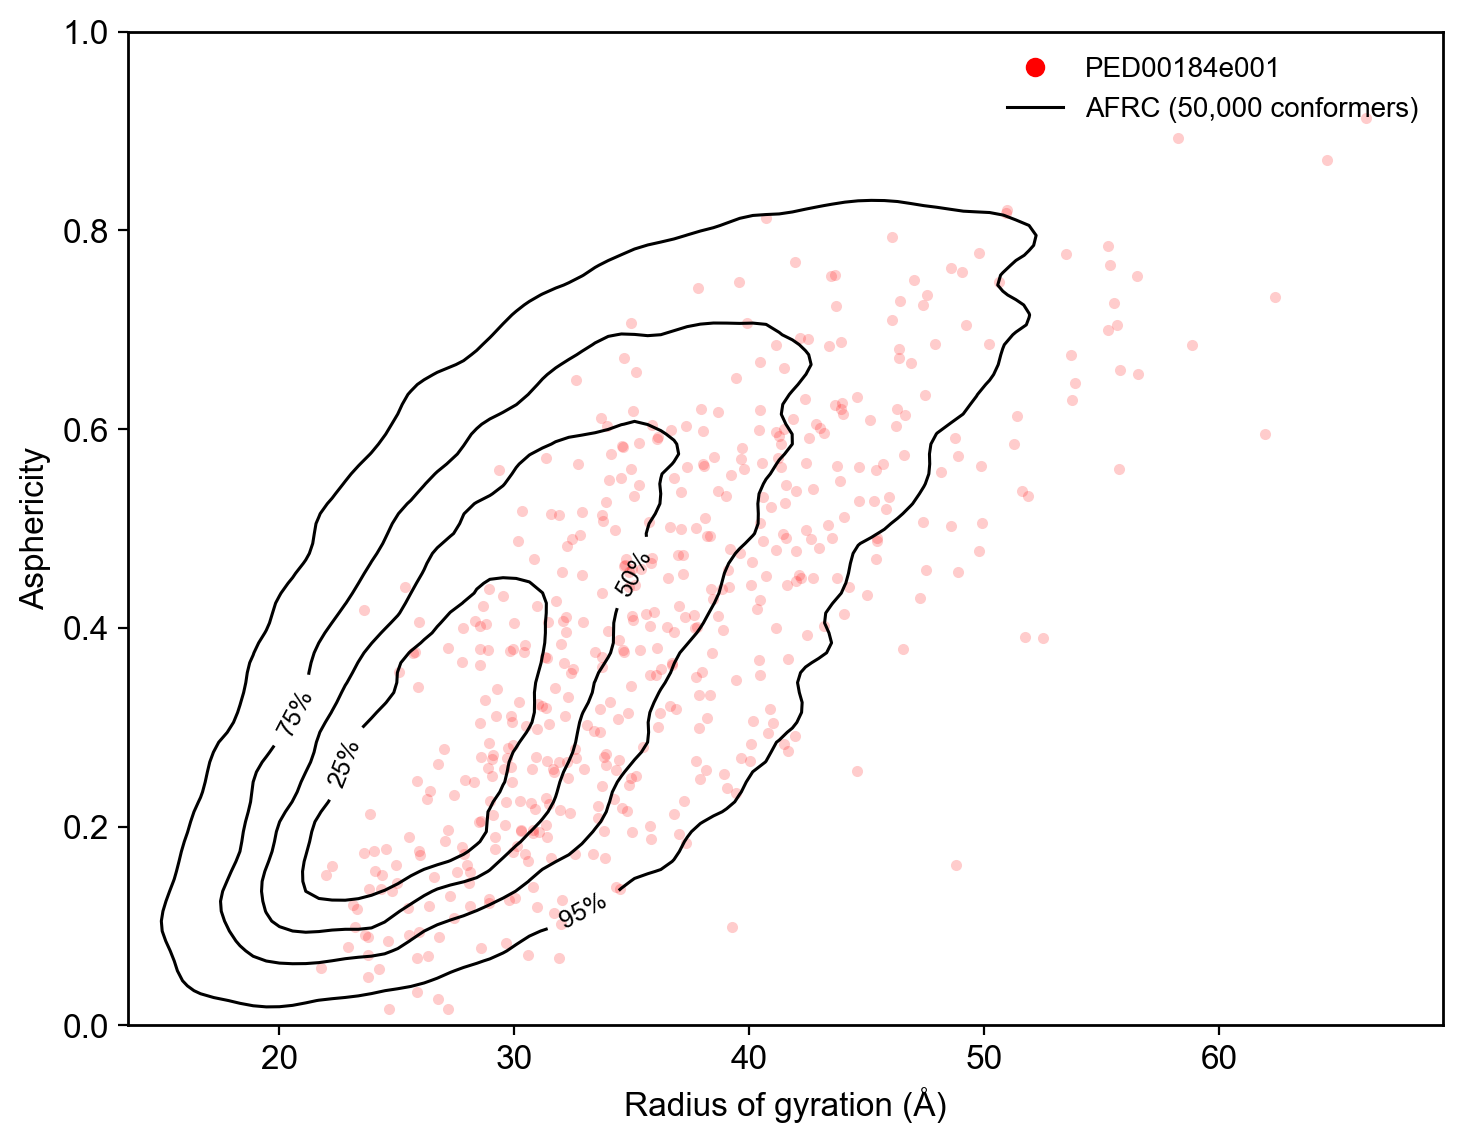

In [14]:
# @title Plot the shape
plot_shape(ensemble, references, save=SAVE_FIGURES)

## Summary

In [15]:
# @title Summarise
print_summary(ensemble, references)

                      PED00184e001      AFRC
Conformers                     500          
Residues                       154          
Mean Rg (Å)                   36.5      31.0
Mean Re (Å)                   88.3      72.2
Mean asphericity             0.401     0.394
Mean helicity                0.070          
Mean β content               0.001          
Disordered (pred.)            100%          

Rg / Rg(AFRC) = 1.18 and Re / Re(AFRC) = 1.22. Above 1 means more expanded than a random coil of this sequence; below 1, more compact.


## Download the figures

If you ticked `SAVE_FIGURES`, this downloads every figure as a PDF, in one zip file.

In [16]:
# @title Download the figures
if SAVE_FIGURES:
    download_figures(ensemble)
else:
    print("To save the figures, tick SAVE_FIGURES at the top and run the notebook again")

To save the figures, tick SAVE_FIGURES at the top and run the notebook again
